In [1]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector, concurrence
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

# Exercise 1

### Create a "product superposition" state $ \ket{+} ⊗ \ket{-}$, measure the qubits and determine if the outcomes are correlated.

Can you predict beforehand if they will be? 

Verify your answer using the concurrence function

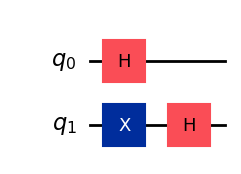

In [10]:
# Answer here

qc = QuantumCircuit(2)
# --------------
qc.h(0)
qc.x(1)
qc.h(1)
qc.draw("mpl")

In [12]:
# --------------
product_state = Statevector.from_circuit(qc)
print("Product state:", product_state)

Product state: Statevector([ 0.5+0.j,  0.5+0.j, -0.5+0.j, -0.5+0.j],
            dims=(2, 2))


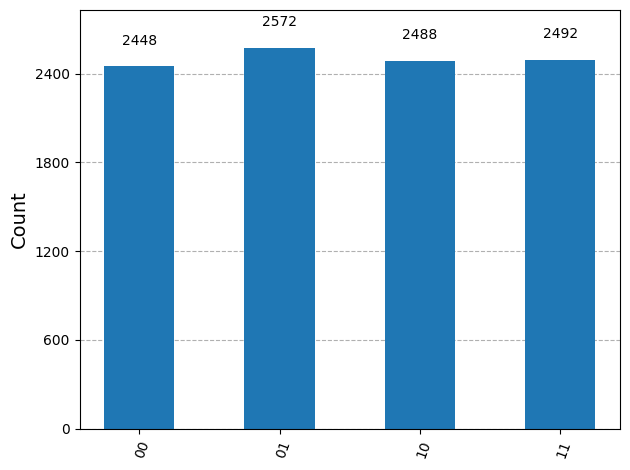

In [13]:
qc.measure_all()

sim = AerSimulator()
result = sim.run(qc, shots=10_000).result()
counts = result.get_counts()
plot_histogram(counts)

In [ ]:
print("Bell state concurrence:", concurrence(product_state))

Bell state concurrence: 0.0


# Exercise 2

## We have seen that the canonical Bell state for the 2 qubit system:

$$
\ket{\Phi^+} = \frac{\ket{00} + \ket{11}}{\sqrt{2}}
$$

## Can you prepare the equivalent for the 3 qubit system?

$$
\ket{\Phi^+} = \frac{\ket{000} + \ket{111}}{\sqrt{2}}
$$

## How about for an n-qubit system?

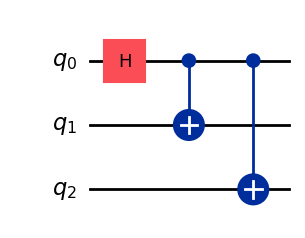

In [14]:
# Answer here

qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)
qc.draw("mpl")

In [18]:
ghz_state = Statevector.from_circuit(qc)
print("GHZ state:", ghz_state)
print("|000> amplitude:", ghz_state[0])
print("|111> amplitude:", ghz_state[7])
print("|101> amplitude:", ghz_state[5])

GHZ state: Statevector([0.70710678+0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.        +0.j, 0.        +0.j,
             0.        +0.j, 0.70710678+0.j],
            dims=(2, 2, 2))
|000> amplitude: (0.7071067811865475+0j)
|111> amplitude: (0.7071067811865475+0j)
|101> amplitude: 0j


# Exercise 3 (Hard)

### Can you prepare an entangled state with 0 < concurrence < 1 ?

<details>
<summary>Hint 1: How to entangle qubits</summary>

Apply a **CNOT gate** to the second qubit, controlled by the first qubit.  
The first qubit must already be in a **superposition**.  
Example in code:

```python
qc.cx(0, 1)  # control qubit 0, target qubit 1
```
</details> 

<details> 
<summary>Hint 2: How to make partial entanglement</summary>

To get concurrence less than 1, the first qubit's superposition must be imbalanced, i.e., not equal probabilities for |0⟩ and |1⟩.
You can do this using an RY rotation:

```python
theta = np.pi/8  # choose 0 < theta < pi/4
qc.ry(2*theta, 0)  # rotate qubit 0 to create an imbalanced superposition
```
</details> 

In [33]:
from qiskit.quantum_info import concurrence
import numpy as np

bell_state = QuantumCircuit(2)

bell_state.h(0)

bell_state.crx(theta=np.pi/2, control_qubit=0, target_qubit=1)

print("Bell state:", Statevector.from_circuit(bell_state))

print("Bell state concurrence:", concurrence(Statevector.from_circuit(bell_state)))

Bell state: Statevector([0.70710678+0.j , 0.5       +0.j , 0.        +0.j ,
             0.        -0.5j],
            dims=(2, 2))
Bell state concurrence: 0.7071067811865478
